# Clustering agroclimático de cultivos (Pareto-80)

**Objetivo:** agrupar las 33 combinaciones `(región, cultivo)` del dataset integrado según su perfil agroclimático y productivo (2020–2025).

| Campo | Valor |
|-------|-------|
| Input | `OUTPUTS/dataset_integrado.csv` |
| Unidad principal | 33 perfiles `(región, cultivo)` |
| Análisis complementario | 2.376 observaciones mensuales (solo clima) |

**Limitación:** clima constante por (región, piso) — ver README y `guion_defensa.md`.

**Decisiones metodológicas:**
- No imputar NaN de producción con cero
- Sin remoción de outliers (IQR/Z-score)
- Métricas DBSCAN: Silhouette calculada excluyendo puntos de ruido (`-1`)


## 1. Instalación e importaciones

### Qué hace esta celda

Importa sklearn, scipy, matplotlib y utilidades para clustering, PCA, NMF y métricas.

In [1]:
# ====================================================================
# CELDA: Importaciones sklearn, scipy y utilidades de visualización
# ====================================================================
# Primer bloque ejecutable del notebook 06 (clustering agroclimático).
# Carga librerías para: agrupamiento (KMeans, jerárquico Ward, DBSCAN),
# reducción de dimensionalidad (PCA, NMF), métricas internas de clusters
# y gráficos de validación (dendrograma, heatmaps, scatter PCA).
# No genera archivos; prepara el entorno numérico reutilizado en todo el análisis.

# --- Librerías estándar ---
# warnings: silencia avisos deprecados durante barridos de K y grid DBSCAN.
# pathlib.Path: rutas relativas al repo (OUTPUTS/, figures/) sin hardcodear SO.
import warnings
from pathlib import Path

# --- Visualización ---
# matplotlib + seaborn: gráficos de selección de K, dendrogramas, heatmaps,
#   barras comparativas y scatter PCA anotado por cultivo.
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# --- Clustering (scipy + sklearn) ---
# linkage / dendrogram: árbol jerárquico aglomerativo (método Ward).
# KMeans: partición en K grupos minimizando inercia — método principal del paper.
# AgglomerativeClustering: jerárquico con K fijo para comparar con KMeans.
# DBSCAN: clustering por densidad; etiqueta -1 = ruido/outlier no asignado.
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering, DBSCAN, KMeans

# --- Reducción de dimensionalidad ---
# PCA: componentes ortogonales que capturan varianza climática (análisis mensual).
# NMF: factorización no negativa sobre datos escalados [0,1] (patrones latentes).
from sklearn.decomposition import PCA, NMF

# --- Métricas internas de calidad de clustering (sklearn.metrics) ---
# silhouette_score: cohesión vs separación en [-1, 1]; mayor = clusters más nítidos.
# davies_bouldin_score: ratio dispersión intra/inter; menor = mejor separación.
# calinski_harabasz_score: varianza entre/sobre clusters; mayor = mejor (usado en barrido K).
# silhouette_samples: Silhouette por observación (reservado para diagnóstico fino).
from sklearn.metrics import (
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_samples,
    silhouette_score,
)

# NearestNeighbors: utilidad para explorar distancias k-NN al calibrar eps en DBSCAN.
from sklearn.neighbors import NearestNeighbors

# --- Escalado de features ---
# StandardScaler: z-score (media 0, std 1) para KMeans/jerárquico/DBSCAN en perfiles.
# MinMaxScaler: escala [0, 1] exigida por NMF (solo valores no negativos).
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Configuración global: ignorar warnings, 120 dpi, estilo whitegrid, paleta tab10.
warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 120
sns.set_style("whitegrid")
PALETTE = sns.color_palette("tab10")
print("Librerías cargadas")



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.1.3 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\USER\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "C:\Users\USER\anaconda3\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\Users\USER\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 701, in start
    self.io_loop.start()
  File "C:\Users\USER\anaconda3\Lib\site-packages

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.1.3 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\USER\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "C:\Users\USER\anaconda3\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\Users\USER\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 701, in start
    self.io_loop.start()
  File "C:\Users\USER\anaconda3\Lib\site-packages

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.1.3 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.



Librerías cargadas


## 2. Carga y exploración

### Qué hace esta celda

Carga `dataset_integrado.csv`, crea carpetas de salida y muestra dimensiones.

In [2]:
# ====================================================================
# CELDA: Carga de dataset_integrado.csv y rutas de salida
# ====================================================================
# Lee la tabla maestra producida por el notebook 03 (merge MIDAGRI + NASA + mapping).
# Input: OUTPUTS/dataset_integrado.csv (~2.376 filas cultivo×mes, 6 regiones Pareto-80).
# Crea OUTPUTS/figures/ para PNGs del clustering. Imprime dimensiones y vista previa.
# La unidad principal del análisis será la agregación posterior a perfil región×cultivo.

# Resolución de ROOT: compatible si el kernel arranca en notebooks/, Clustering/ o repo raíz.
ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent.parent
elif ROOT.name == "Clustering":
    ROOT = ROOT.parent

# Rutas de insumo (CSV integrado) y salida (CSVs + figuras de clustering).
RUTA_DATA = ROOT / "OUTPUTS" / "dataset_integrado.csv"
RUTA_OUT = ROOT / "OUTPUTS"
RUTA_FIG = RUTA_OUT / "figures"
RUTA_FIG.mkdir(parents=True, exist_ok=True)

# Carga en memoria: cada fila = un mes de un cultivo Pareto en un distrito/piso/región.
df = pd.read_csv(RUTA_DATA)
print(f"Dimensiones: {df.shape[0]:,} filas x {df.shape[1]} columnas")
print(f"Combinaciones (región, cultivo): {df.groupby(['region', 'cultivo']).ngroups}")
print("Columnas:", list(df.columns))
df.head()


Dimensiones: 2,376 filas x 20 columnas
Combinaciones (región, cultivo): 33
Columnas: ['region', 'piso_ecologico', 'distrito', 'cultivo', 'anio', 'numero_mes', 'mes', 'produccion_ton', 'temp_promedio', 'temp_maxima', 'temp_minima', 'precipitacion', 'humedad_relativa', 'radiacion_solar', 'velocidad_viento', 'presion_atmosferica', 'humedad_suelo', 'temp_superficie', 'punto_rocio', 'humedad_especifica']


,region,piso_ecologico,distrito,cultivo,anio,numero_mes,mes,produccion_ton,temp_promedio,temp_maxima,temp_minima,precipitacion,humedad_relativa,radiacion_solar,velocidad_viento,presion_atmosferica,humedad_suelo,temp_superficie,punto_rocio,humedad_especifica
0,Ica,costa,Chincha Alta,alfalfa,2020,1,Enero,10684.89,21.96,27.55,18.21,0.12,78.45,22.25,2.99,95.82,0.33,23.95,17.83,13.41
1,Ica,costa,Chincha Alta,esparrago,2020,1,Enero,14799.60,21.96,27.55,18.21,0.12,78.45,22.25,2.99,95.82,0.33,23.95,17.83,13.41
2,Ica,costa,Chincha Alta,maiz_amarillo_duro,2020,1,Enero,9000.19,21.96,27.55,18.21,0.12,78.45,22.25,2.99,95.82,0.33,23.95,17.83,13.41
3,Ica,costa,Chincha Alta,mandarina,2020,1,Enero,0.00,21.96,27.55,18.21,0.12,78.45,22.25,2.99,95.82,0.33,23.95,17.83,13.41
4,Ica,costa,Chincha Alta,palta,2020,1,Enero,7.10,21.96,27.55,18.21,0.12,78.45,22.25,2.99,95.82,0.33,23.95,17.83,13.41


### Qué hace esta celda

Lista regiones, pisos, cultivos y define `CLIMA_VARS` / `CLIMA_CORE`.

In [3]:
# ====================================================================
# CELDA: Variables climáticas NASA y exploración básica del dataset
# ====================================================================
# Define las 12 variables descargadas de NASA POWER y el subconjunto CLIMA_CORE
# (5 variables interpretables usadas en la agregación de perfiles).
# Imprime regiones, pisos ecológicos, número de cultivos y NaN en producción.
# Contexto: el clima es idéntico para todos los cultivos del mismo distrito/mes.

# Lista completa de variables climáticas (12 columnas NASA en dataset_integrado).
CLIMA_VARS = [
    "temp_promedio", "temp_maxima", "temp_minima", "precipitacion",
    "humedad_relativa", "radiacion_solar", "velocidad_viento",
    "presion_atmosferica", "humedad_suelo", "temp_superficie",
    "punto_rocio", "humedad_especifica",
]

# Subconjunto reducido para perfiles: temperatura, lluvia, humedad, radiación, suelo.
CLIMA_CORE = [
    "temp_promedio", "precipitacion", "humedad_relativa",
    "radiacion_solar", "humedad_suelo",
]

# Auditoría exploratoria antes de agregar perfiles.
print("Regiones :", sorted(df["region"].unique()))
print("Pisos    :", sorted(df["piso_ecologico"].unique()))
print("Cultivos :", df["cultivo"].nunique())
print("NaN produccion_ton:", df["produccion_ton"].isna().sum())


Regiones : ['Ica', 'Junin', 'La Libertad', 'Piura', 'Puno', 'San Martin']
Pisos    : ['altiplano_lacustre', 'bosque_seco', 'costa', 'puna_alta', 'selva_alta', 'selva_alto_mayo', 'selva_baja', 'selva_huallaga', 'sierra', 'valle_chira']
Cultivos : 19
NaN produccion_ton: 166


## 3. Funciones auxiliares de clustering

Reutilizables en el análisis por perfiles y el análisis mensual complementario.

### Qué hace esta celda

Define funciones: `eval_kmeans_range`, `elegir_k`, `grid_dbscan`, `plot_k_selection`, etc.

In [4]:
# ====================================================================
# CELDA: Funciones auxiliares — métricas, barrido K, DBSCAN y gráficos
# ====================================================================
# Define utilidades reutilizadas en todo el notebook:
#   - Métricas adaptadas a DBSCAN (Silhouette sin ruido, % puntos -1).
#   - eval_kmeans_range: barrido K=2..8 con Silhouette, Calinski, Davies-Bouldin.
#   - elegir_k: consenso entre mejor Silhouette y mejor Davies-Bouldin.
#   - grid_dbscan: búsqueda en rejilla (eps × min_samples).
#   - plot_k_selection: panel codo + Silhouette + Davies-Bouldin.
# Estas funciones encapsulan la lógica de validación interna de clusters.

# Rango por defecto de K a evaluar en KMeans (particiones de 2 a 8 clusters).
K_RANGE = range(2, 9)


# Silhouette excluyendo etiquetas -1 (ruido DBSCAN): evita sesgar la métrica
# con puntos no asignados que no pertenecen a ningún cluster denso.
def silhouette_no_noise(X, labels):
    mask = labels >= 0
    labs = labels[mask]
    if len(set(labs)) < 2 or mask.sum() < 3:
        return np.nan
    return float(silhouette_score(X[mask], labs))


# Porcentaje de observaciones marcadas como ruido (etiqueta -1) por DBSCAN.
def pct_ruido(labels):
    return 100.0 * (labels < 0).mean()


# Barrido sistemático de K en KMeans: para cada K guarda inercia, Silhouette,
# Calinski-Harabasz, Davies-Bouldin, etiquetas y el modelo ajustado.
def eval_kmeans_range(X, k_range=K_RANGE, random_state=42):
    rows = []
    for k in k_range:
        # n_init=10: múltiples inicializaciones aleatorias para evitar mínimos locales.
        km = KMeans(n_clusters=k, random_state=random_state, n_init=10)
        lbl = km.fit_predict(X)
        rows.append({
            "k": k,
            "inertia": km.inertia_,
            "silhouette": silhouette_score(X, lbl),
            "calinski": calinski_harabasz_score(X, lbl),
            "davies_bouldin": davies_bouldin_score(X, lbl),
            "labels": lbl,
            "model": km,
        })
    return pd.DataFrame(rows)


# Selección de K óptimo: si Silhouette y Davies-Bouldin coinciden, usar ese K;
# si no, promediar rankings de ambas métricas (compromiso interpretabilidad/calidad).
def elegir_k(df_km):
    best_sil = int(df_km.loc[df_km["silhouette"].idxmax(), "k"])
    best_db = int(df_km.loc[df_km["davies_bouldin"].idxmin(), "k"])
    if best_sil == best_db:
        return best_sil, "coincidencia Silhouette y Davies-Bouldin"
    rank_sil = df_km.set_index("k")["silhouette"].rank(ascending=False)
    rank_db = df_km.set_index("k")["davies_bouldin"].rank(ascending=True)
    k_opt = int((rank_sil + rank_db).idxmin())
    return k_opt, f"ranking promedio (Sil={best_sil}, DB={best_db})"


# Rejilla DBSCAN: prueba combinaciones (eps, min_samples), descarta configs con <2 clusters,
# ordena por Silhouette (sin ruido). eps = radio de vecindad; min_samples = densidad mínima.
def grid_dbscan(X, eps_list, ms_list):
    rows = []
    for eps in eps_list:
        for ms in ms_list:
            # fit_predict asigna -1 a puntos en regiones de baja densidad.
            lbl = DBSCAN(eps=eps, min_samples=ms).fit_predict(X)
            n_cl = len(set(lbl)) - (1 if -1 in lbl else 0)
            if n_cl < 2:
                continue
            rows.append({
                "eps": eps,
                "min_samples": ms,
                "n_clusters": n_cl,
                "pct_ruido": pct_ruido(lbl),
                "silhouette": silhouette_no_noise(X, lbl),
                "davies_bouldin": davies_bouldin_score(X[lbl >= 0], lbl[lbl >= 0]),
                "labels": lbl,
            })
    if not rows:
        return pd.DataFrame()
    return pd.DataFrame(rows).sort_values("silhouette", ascending=False)


# Panel de diagnóstico visual para elegir K: inercia (método del codo), Silhouette y Davies-Bouldin.
def plot_k_selection(df_km, titulo):
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    # Panel 1: curva de inercia — buscar "codo" donde añadir clusters aporta poco.
    axes[0].plot(df_km["k"], df_km["inertia"], "o-", color="steelblue")
    axes[0].set_title("Codo (inercia)")
    axes[0].set_xlabel("K")
    # Panel 2: Silhouette por K — línea roja en el K con mayor cohesión/separación.
    best_sil = int(df_km.loc[df_km["silhouette"].idxmax(), "k"])
    axes[1].plot(df_km["k"], df_km["silhouette"], "o-", color="green")
    axes[1].axvline(best_sil, color="red", ls="--", label=f"K={best_sil}")
    axes[1].set_title("Silhouette")
    axes[1].legend()
    # Panel 3: Davies-Bouldin por K — línea en el K con menor dispersión relativa.
    best_db = int(df_km.loc[df_km["davies_bouldin"].idxmin(), "k"])
    axes[2].plot(df_km["k"], df_km["davies_bouldin"], "o-", color="crimson")
    axes[2].axvline(best_db, color="navy", ls="--", label=f"K={best_db}")
    axes[2].set_title("Davies-Bouldin")
    axes[2].legend()
    plt.suptitle(titulo, fontweight="bold")
    plt.tight_layout()
    plt.show()


## 4. Análisis principal — perfiles por (región, cultivo)

Una fila por combinación Pareto-80 (~30). Agrega clima (media y desv. estándar) y producción sin imputar ceros en meses faltantes.

### Qué hace esta celda

Agrega perfiles (región×cultivo): medias/std climáticas, producción total, CV; estandariza features.

In [5]:
# ====================================================================
# CELDA: Agregación de perfiles región×cultivo (unidad principal del análisis)
# ====================================================================
# Colapsa las ~72 filas mensuales de cada par (región, cultivo, piso, distrito)
# en UN perfil agroclimático-productivo con features interpretables:
#   - Producción: total, media en meses de cosecha, coeficiente de variación.
#   - Clima CLIMA_CORE: media y desviación estándar temporal por variable.
# Estandariza con StandardScaler → matriz X_perfil para KMeans/jerárquico/DBSCAN.
# Output: df_perfil (~33 filas) y X_perfil (numpy array z-score).

# Coeficiente de variación (std/mean) solo en meses con producción estrictamente > 0.
def coef_var_positivos(s):
    v = s.dropna()
    v = v[v > 0]
    if len(v) < 2 or v.mean() == 0:
        return np.nan
    return v.std() / v.mean()


# Diccionario de agregaciones pandas: tuplas (columna_origen, función).
agg_dict = {
    "produccion_total": ("produccion_ton", lambda s: s.dropna().sum()),
    "produccion_media_cosecha": (
        "produccion_ton",
        lambda s: s[s > 0].mean() if (s > 0).any() else np.nan,
    ),
    "coef_var_produccion": ("produccion_ton", coef_var_positivos),
    "n_meses_con_dato": ("produccion_ton", lambda s: s.notna().sum()),
    "n_meses_cosecha": ("produccion_ton", lambda s: (s > 0).sum()),
}

# Por cada variable CLIMA_CORE añadir media y std temporal al perfil.
for v in CLIMA_CORE:
    agg_dict[f"{v}_mean"] = (v, "mean")
    agg_dict[f"{v}_std"] = (v, "std")

# groupby: una fila por combinación región×cultivo×piso×distrito (33 perfiles Pareto-80).
df_perfil = df.groupby(
    ["region", "cultivo", "piso_ecologico", "distrito"], as_index=False
).agg(**agg_dict)

# Etiqueta legible para dendrograma y anotaciones: "Región | cultivo".
df_perfil["etiqueta"] = df_perfil["region"] + " | " + df_perfil["cultivo"]

# Lista de columnas numéricas que alimentan el clustering (clima mean/std + producción).
FEATURES_PERFIL = [c for c in df_perfil.columns if c.endswith("_mean") or c.endswith("_std")]
FEATURES_PERFIL += [
    "produccion_total", "produccion_media_cosecha", "coef_var_produccion",
]

# Matriz cruda y estandarizada: KMeans asume features en escala comparable.
X_perfil_raw = df_perfil[FEATURES_PERFIL].copy()
scaler_perfil = StandardScaler()
X_perfil = scaler_perfil.fit_transform(X_perfil_raw)

print(f"Perfiles: {df_perfil.shape[0]} filas x {len(FEATURES_PERFIL)} features")
df_perfil[["region", "cultivo", "produccion_total", "n_meses_cosecha"]].head(10)


Perfiles: 33 filas x 13 features


,region,cultivo,produccion_total,n_meses_cosecha
0,Ica,alfalfa,757682.175,68
1,Ica,esparrago,959796.239,68
2,Ica,maiz_amarillo_duro,924060.716,68
3,Ica,mandarina,1106303.998,51
4,Ica,palta,645631.289,49
5,Ica,papa,791326.750,62
6,Ica,tomate,702007.144,68
7,Ica,uva,2632079.829,53
8,Junin,alfalfa,829310.310,68
9,Junin,avena_forrajera,614215.500,68


### Qué hace esta celda

Sweep K=2–7 con KMeans sobre perfiles; elige K por Silhouette/Davies–Bouldin; gráfico `seleccion_k_perfiles.png`.

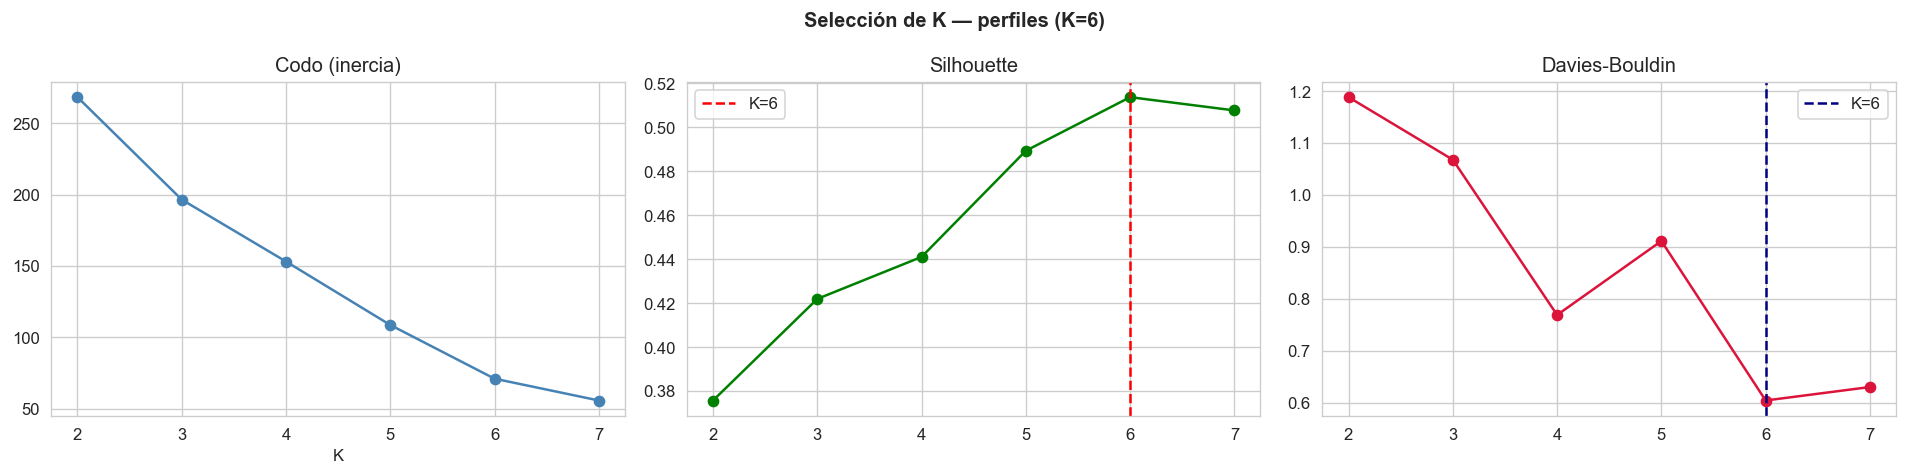

K óptimo perfiles: 6 (coincidencia Silhouette y Davies-Bouldin)
Silhouette=0.5137  Davies-Bouldin=0.6040


In [6]:
# ====================================================================
# CELDA: KMeans sobre perfiles — selección de K y ajuste final
# ====================================================================
# Análisis PRINCIPAL del notebook: clustering de los ~33 perfiles estandarizados.
# 1) Barrido K=2..7 con eval_kmeans_range y panel plot_k_selection.
# 2) elegir_k determina K_PERFIL (típicamente K=6 en la versión actual).
# 3) KMeans final: asigna cluster_kmeans, calcula Silhouette y Davies-Bouldin.
# Figura esperada: seleccion_k_perfiles.png (generada por plot_k_selection si se guarda).

# Barrido de K sobre X_perfil (espacio z-score de features agroclimáticas).
km_perfil_df = eval_kmeans_range(X_perfil, k_range=range(2, 8))
K_PERFIL, motivo_k = elegir_k(km_perfil_df)
plot_k_selection(km_perfil_df, f"Selección de K — perfiles (K={K_PERFIL})")
print(f"K óptimo perfiles: {K_PERFIL} ({motivo_k})")

# Modelo definitivo KMeans con K_PERFIL clusters sobre perfiles.
km_perfil = KMeans(n_clusters=K_PERFIL, random_state=42, n_init=10)
labels_perfil_km = km_perfil.fit_predict(X_perfil)
df_perfil["cluster_kmeans"] = labels_perfil_km

# Métricas de calidad del particionado final (referencia para tabla comparativa).
sil_perfil_km = silhouette_score(X_perfil, labels_perfil_km)
db_perfil_km = davies_bouldin_score(X_perfil, labels_perfil_km)
print(f"Silhouette={sil_perfil_km:.4f}  Davies-Bouldin={db_perfil_km:.4f}")


### Interpretación — selección de K (`seleccion_k_perfiles.png`)

Muestra Silhouette y Davies–Bouldin para K=2…7 sobre **33 perfiles**. El K elegido balancea separación de clusters e interpretabilidad agronómica (K=6 en la versión actual). Un K muy alto fragmenta cultivos similares; uno muy bajo mezcla costa y selva.

### Qué hace esta celda

Dendrograma Ward + clustering jerárquico con el mismo K; guarda `dendrograma_perfiles.png`.

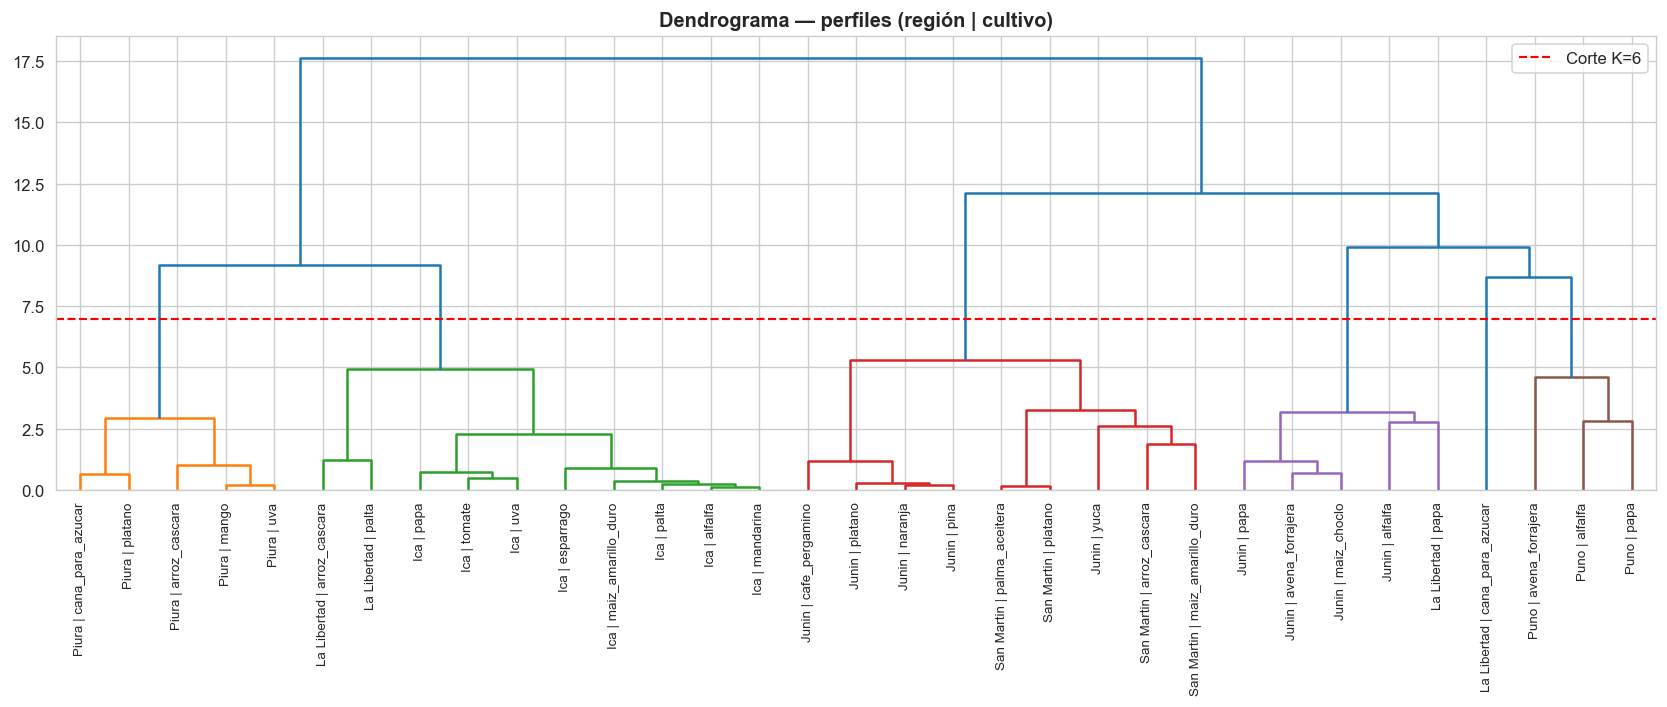

Jerárquico K=6 | Silhouette=0.5137


In [7]:
# ====================================================================
# CELDA: Clustering jerárquico aglomerativo (Ward) y dendrograma
# ====================================================================
# Complementa KMeans con enfoque bottom-up: fusiones Ward minimizan varianza intra-grupo.
# 1) linkage() construye matriz de fusiones sobre X_perfil estandarizado.
# 2) dendrogram() visualiza el árbol con etiquetas región|cultivo.
# 3) AgglomerativeClustering con mismo K_PERFIL para comparar asignaciones.
# Output PNG: OUTPUTS/figures/dendrograma_perfiles.png

# Matriz de enlace jerárquico (método Ward = distancia euclídea en espacio estandarizado).
Z = linkage(X_perfil, method="ward")

# Altura de corte que produce K_PERFIL clusters: punto medio entre las dos
# fusiones que llevan de K a K-1 grupos (linea roja discontinua en el grafico).
thr = (Z[-K_PERFIL, 2] + Z[-(K_PERFIL - 1), 2]) / 2

# Dendrograma: altura de fusión indica disimilitud; hojas = perfiles individuales.
fig, ax = plt.subplots(figsize=(14, 6))
dendrogram(
    Z,
    labels=df_perfil["etiqueta"].tolist(),
    leaf_rotation=90,
    leaf_font_size=8,
    color_threshold=thr,
    ax=ax,
)
ax.axhline(thr, color="red", ls="--", lw=1.3, label=f"Corte K={K_PERFIL}")
ax.legend(loc="upper right")
ax.set_title("Dendrograma — perfiles (región | cultivo)", fontweight="bold")
plt.tight_layout()
plt.savefig(RUTA_FIG / "dendrograma_perfiles.png", dpi=150, bbox_inches="tight")
plt.show()

# Clustering jerárquico con K fijo = K_PERFIL (misma cardinalidad que KMeans).
hc = AgglomerativeClustering(n_clusters=K_PERFIL, linkage="ward")
labels_perfil_hc = hc.fit_predict(X_perfil)
df_perfil["cluster_jerarquico"] = labels_perfil_hc
sil_perfil_hc = silhouette_score(X_perfil, labels_perfil_hc)
print(f"Jerárquico K={K_PERFIL} | Silhouette={sil_perfil_hc:.4f}")


### Interpretación — dendrograma (`dendrograma_perfiles.png`)

Árbol jerárquico Ward: cultivos que se fusionan a baja altura son perfiles similares en el espacio clima+producción estandarizado. Útil para validar si KMeans respeta estructura natural (costa, selva, altiplano).

### Qué hace esta celda

Grid DBSCAN sobre perfiles; reporta % ruido (suele ser alto → método complementario).

In [8]:
# ====================================================================
# CELDA: DBSCAN sobre perfiles — grid de hiperparámetros
# ====================================================================
# DBSCAN no requiere K a priori pero es sensible a eps y min_samples en espacio z-score.
# Se prueba una rejilla reducida; se elige la config con mayor Silhouette (sin ruido).
# En perfiles suele haber alto % de ruido → método complementario, no principal.
# Guarda cluster_dbscan, sil_perfil_db y pct_noise_p para la tabla comparativa.

# Rejilla DBSCAN sobre X_perfil: eps en unidades de desviación estándar.
res_db_perfil = grid_dbscan(
    X_perfil,
    eps_list=[0.8, 1.0, 1.2, 1.5, 2.0, 2.5],
    ms_list=[2, 3, 4],
)

if len(res_db_perfil):
    # Mejor fila = mayor Silhouette tras excluir puntos -1.
    best_db_p = res_db_perfil.iloc[0]
    labels_perfil_db = best_db_p["labels"].astype(int)
    df_perfil["cluster_dbscan"] = labels_perfil_db
    sil_perfil_db = best_db_p["silhouette"]
    pct_noise_p = best_db_p["pct_ruido"]
    print("Top DBSCAN perfiles:")
    print(res_db_perfil[["eps", "min_samples", "n_clusters", "pct_ruido", "silhouette"]].head(5).to_string(index=False))
else:
    # Sin configuración válida: todos los perfiles marcados como ruido (-1).
    labels_perfil_db = np.full(len(df_perfil), -1)
    df_perfil["cluster_dbscan"] = labels_perfil_db
    sil_perfil_db = np.nan
    pct_noise_p = 100.0
    print("DBSCAN perfiles: sin configuración válida")


Top DBSCAN perfiles:
 eps  min_samples  n_clusters  pct_ruido  silhouette
 1.0            4           2  63.636364    0.856869
 0.8            3           3  57.575758    0.854312
 0.8            2           6  39.393939    0.823917
 1.0            3           4  45.454545    0.808065
 1.2            4           3  51.515152    0.785034


### 4.1 Interpretación de clusters (perfiles)

### Qué hace esta celda

Tabla de asignaciones, crosstab por región y heatmap de centroides → `heatmap_perfiles_kmeans.png`.

     region            cultivo     piso_ecologico     distrito  cluster_kmeans  cluster_jerarquico  cluster_dbscan  produccion_total
      Junin     cafe_pergamino         selva_alta       Perene               0                   0               1      3.700464e+05
      Junin            naranja         selva_alta       Perene               0                   0               1      1.734258e+06
      Junin               pina         selva_alta       Perene               0                   0               1      2.527248e+06
      Junin            platano         selva_alta       Perene               0                   0               1      1.244001e+06
      Junin               yuca         selva_baja    Rio Tambo               0                   0              -1      6.969515e+05
 San Martin      arroz_cascara    selva_alto_mayo    Moyobamba               0                   0              -1      4.913001e+06
 San Martin maiz_amarillo_duro    selva_alto_mayo    Moyobamba       

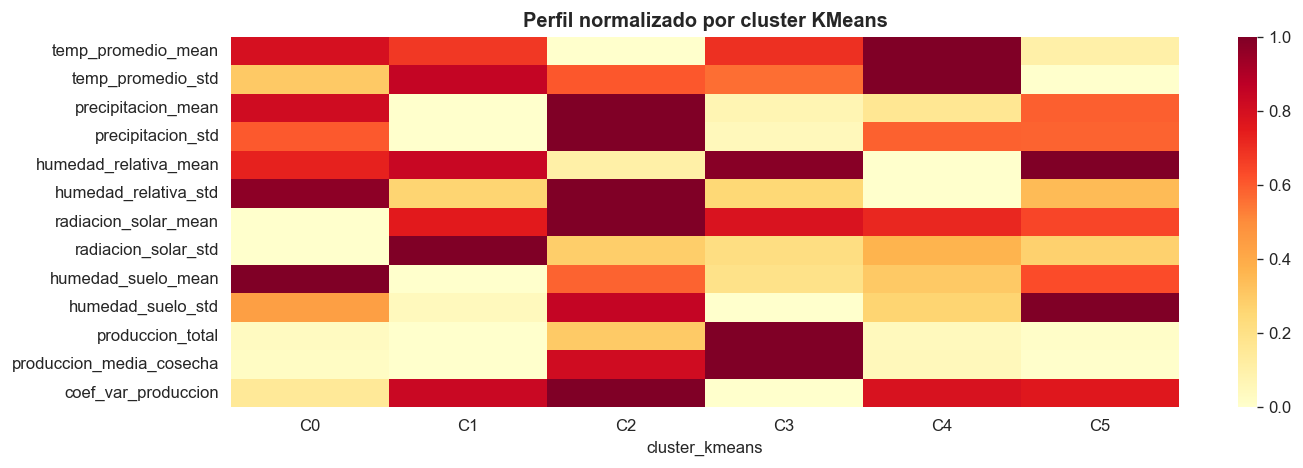

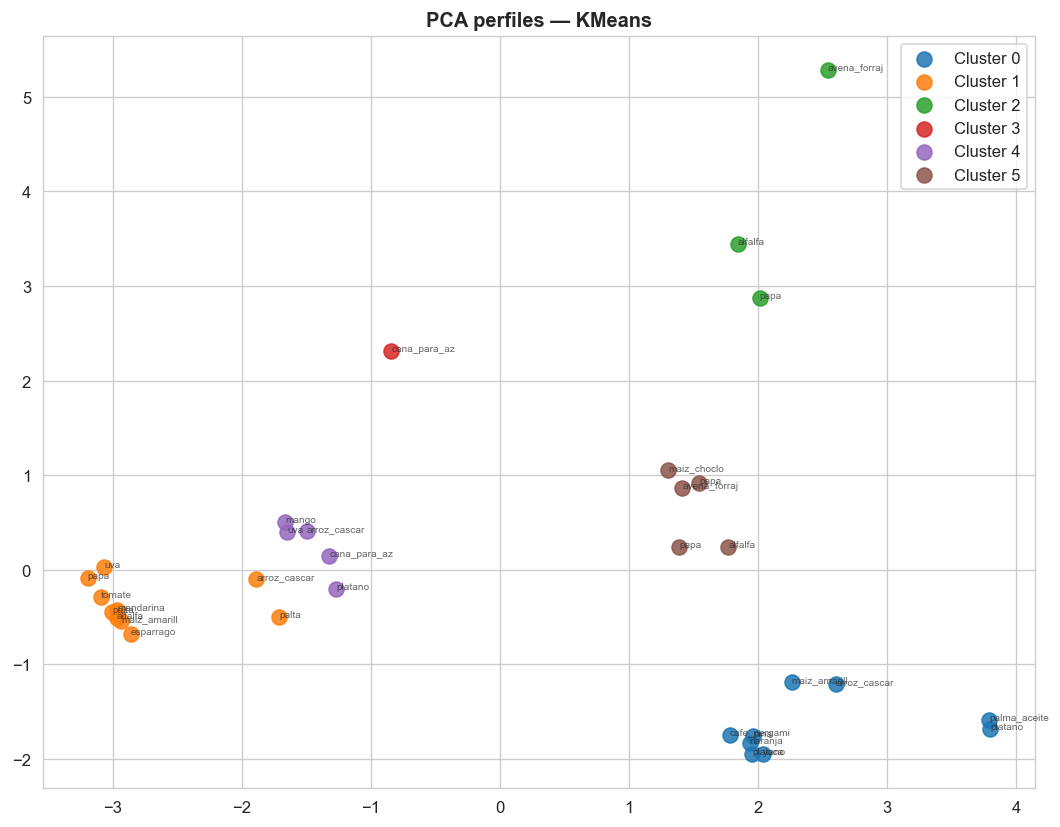

In [9]:
# ====================================================================
# CELDA: Tabla de asignaciones, heatmap de centroides y PCA 2D de perfiles
# ====================================================================
# Consolida resultados del bloque principal (perfiles):
#   - tabla_perfil: asignaciones KMeans, jerárquico y DBSCAN por cultivo.
#   - crosstab: composición de cada cluster KMeans por región.
#   - heatmap: centroides normalizados min-max por variable → heatmap_perfiles_kmeans.png.
#   - scatter PCA 2D coloreado por cluster KMeans con anotación de cultivos.

# Tabla ordenada: región, cultivo, piso, distrito, tres métodos y producción total.
tabla_perfil = df_perfil[
    ["region", "cultivo", "piso_ecologico", "distrito",
     "cluster_kmeans", "cluster_jerarquico", "cluster_dbscan", "produccion_total"]
].sort_values(["cluster_kmeans", "region", "cultivo"])
print(tabla_perfil.to_string(index=False))

# Crosstab: cuántos cultivos de cada región caen en cada cluster KMeans.
comp_region = pd.crosstab(df_perfil["cluster_kmeans"], df_perfil["region"])
print("\nComposición KMeans por región:")
print(comp_region)

# Centroides KMeans: media de cada feature por cluster; normalización 0-1 para heatmap.
cent = df_perfil.groupby("cluster_kmeans")[FEATURES_PERFIL].mean()
cent_norm = (cent - cent.min()) / (cent.max() - cent.min() + 1e-9)

fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(cent_norm.T, annot=False, cmap="YlOrRd", ax=ax)
ax.set_title("Perfil normalizado por cluster KMeans", fontweight="bold")
ax.set_xticklabels([f"C{i}" for i in cent.index])
plt.tight_layout()
plt.savefig(RUTA_FIG / "heatmap_perfiles_kmeans.png", dpi=150, bbox_inches="tight")
plt.show()

# PCA con 2 componentes sobre perfiles: proyección visual del espacio de clustering.
pca_p = PCA(n_components=2, random_state=42)
xy_p = pca_p.fit_transform(X_perfil)

fig, ax = plt.subplots(figsize=(9, 7))
for c in sorted(df_perfil["cluster_kmeans"].unique()):
    m = df_perfil["cluster_kmeans"] == c
    ax.scatter(xy_p[m, 0], xy_p[m, 1], label=f"Cluster {c}", s=80, alpha=0.85)
for idx, (_, row) in enumerate(df_perfil.iterrows()):
    ax.annotate(row["cultivo"][:12], (xy_p[idx, 0], xy_p[idx, 1]), fontsize=6, alpha=0.7)
ax.set_title("PCA perfiles — KMeans", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()


### Interpretación — heatmap perfiles (`heatmap_perfiles_kmeans.png`)

Filas = clusters KMeans; columnas = variables (medias climáticas y producción). Permite nombrar clusters: ej. alto volumen costero, selva húmeda, altiplano frío, outlier caña La Libertad.

### Qué hace esta celda

Impresión narrativa de composición climática-productiva por cluster KMeans.

### 4.2 Mapa geográfico de clusters (Folium)

Ubica cada perfil `(región, cultivo)` en las coordenadas exactas del **distrito proxy** NASA (notebook 02). Varios cultivos de la misma región comparten el mismo punto (ej. 8 cultivos de Ica → Chincha Alta); **MarkerCluster** los agrupa al hacer zoom y evita desplazarlos artificialmente al mar.

**Limitación:** el mapa muestra dónde está el proxy climático asignado, no la extensión real de cada cultivo en el territorio.

**Cómo ver el mapa:**
1. Extensión **Live Server** (`ritwickdey.LiveServer`) en Cursor.
2. Clic derecho en `OUTPUTS/figures/mapa_clusters_folium.html` → **Open with Live Server**.
3. O usa el enlace que imprime la celda siguiente: `http://127.0.0.1:5500/OUTPUTS/figures/mapa_clusters_folium.html`

El mapa **no** se embebe en el cuaderno; solo se exporta como HTML.

In [10]:
# ====================================================================
# CELDA: Mapa geográfico interactivo de clusters (Folium)
# ====================================================================
# Une df_perfil con lat/lon de los 14 distritos NASA (notebook 02).
# Jitter circular por distrito para separar cultivos que comparten proxy.
# Exporta HTML interactivo en OUTPUTS/figures/mapa_clusters_folium.html.

!pip install folium==0.19.5

import folium
from branca.element import Element
from folium.plugins import MarkerCluster
from IPython.display import HTML, display

COORDS_DISTRITOS = pd.DataFrame([
    {"distrito": "Chincha Alta", "lat": -13.4099, "lon": -76.1324},
    {"distrito": "Viru", "lat": -8.4143, "lon": -78.7524},
    {"distrito": "Huamachuco", "lat": -7.8121, "lon": -78.0487},
    {"distrito": "Cascas", "lat": -7.4797, "lon": -78.8178},
    {"distrito": "Tambogrande", "lat": -4.9269, "lon": -80.3447},
    {"distrito": "Sullana", "lat": -4.9039, "lon": -80.6853},
    {"distrito": "Canchaque", "lat": -5.3760, "lon": -79.6098},
    {"distrito": "Moyobamba", "lat": -6.0344, "lon": -76.9742},
    {"distrito": "Tocache", "lat": -8.1877, "lon": -76.5205},
    {"distrito": "Perene", "lat": -10.9489, "lon": -75.2264},
    {"distrito": "Rio Tambo", "lat": -11.1656, "lon": -74.2353},
    {"distrito": "El Tambo", "lat": -12.0313, "lon": -75.2222},
    {"distrito": "Ilave", "lat": -16.0866, "lon": -69.6354},
    {"distrito": "Ayaviri", "lat": -14.8864, "lon": -70.5889},
])


def _rgb_to_hex(rgb):
    return "#{:02x}{:02x}{:02x}".format(
        int(rgb[0] * 255), int(rgb[1] * 255), int(rgb[2] * 255)
    )


map_df = df_perfil.merge(COORDS_DISTRITOS, on="distrito", how="left")
missing = map_df["lat"].isna().sum()
if missing:
    print(f"Advertencia: {missing} perfiles sin coordenadas (revisar nombre de distrito).")

cluster_ids = sorted(map_df["cluster_kmeans"].dropna().unique())
cluster_colors = {c: _rgb_to_hex(PALETTE[int(c) % len(PALETTE)]) for c in cluster_ids}

m = folium.Map(location=[-9.5, -75.5], zoom_start=5, tiles="CartoDB positron")
m.get_root().width = "100%"
m.get_root().height = "620px"

fg_distritos = folium.FeatureGroup(name="Distritos proxy (NASA)", show=True)
for _, row in COORDS_DISTRITOS.iterrows():
    folium.CircleMarker(
        location=[row["lat"], row["lon"]],
        radius=4,
        color="#666666",
        weight=1,
        fill=True,
        fill_color="#bbbbbb",
        fill_opacity=0.35,
        popup=f"<b>{row['distrito']}</b><br>Proxy climático NASA POWER",
    ).add_to(fg_distritos)
fg_distritos.add_to(m)

fg_perfiles = MarkerCluster(name="Perfiles Pareto-80 (KMeans)", show=True).add_to(m)
for _, row in map_df.iterrows():
    if pd.isna(row["lat"]):
        continue
    cluster = int(row["cluster_kmeans"])
    color = cluster_colors[cluster]
    popup_html = (
        f"<b>{row['region']} | {row['cultivo']}</b><br>"
        f"Cluster KMeans: {cluster}<br>"
        f"Distrito proxy: {row['distrito']}<br>"
        f"Piso: {row['piso_ecologico']}<br>"
        f"Producción total: {row['produccion_total']:,.0f} t"
    )
    folium.CircleMarker(
        location=[row["lat"], row["lon"]],
        radius=7,
        color=color,
        weight=2,
        fill=True,
        fill_color=color,
        fill_opacity=0.85,
        popup=folium.Popup(popup_html, max_width=320),
        tooltip=f"C{cluster}: {row['region']} | {row['cultivo']}",
    ).add_to(fg_perfiles)

legend_items = "".join(
    f'<div><span style="background:{cluster_colors[c]};opacity:0.85;'
    f'display:inline-block;width:14px;height:14px;margin-right:6px;border:1px solid #333;"></span>'
    f'Cluster {c}</div>'
    for c in cluster_ids
)
legend_html = f"""
<div style="position: fixed; bottom: 24px; left: 24px; z-index: 9999;
            background: white; padding: 10px 12px; border: 1px solid #ccc;
            border-radius: 4px; font-size: 12px; line-height: 1.5;">
  <b>Clusters KMeans</b><br>{legend_items}
  <hr style="margin:6px 0;">
  <span style="color:#666;">Círculos grises = 14 distritos proxy NASA</span>
</div>
"""
m.get_root().html.add_child(Element(legend_html))

folium.LayerControl(collapsed=False).add_to(m)

ruta_mapa = RUTA_FIG / "mapa_clusters_folium.html"
m.save(str(ruta_mapa))
print(f"Mapa exportado: {ruta_mapa}")

url_live_server = "http://127.0.0.1:5500/OUTPUTS/figures/mapa_clusters_folium.html"
print(f"Live Server: {url_live_server}")
print("  → Clic derecho en mapa_clusters_folium.html → Open with Live Server")

display(HTML(
    f'<p><b>Mapa interactivo</b> — '
    f'<a href="{url_live_server}" target="_blank">Abrir con Live Server</a></p>'
))

Mapa exportado: C:\Users\USER\OneDrive\Escritorio\Github\DM_TF\OUTPUTS\figures\mapa_clusters_folium.html
Live Server: http://127.0.0.1:5500/OUTPUTS/figures/mapa_clusters_folium.html
  → Clic derecho en mapa_clusters_folium.html → Open with Live Server


In [11]:
# ====================================================================
# CELDA: Perfil narrativo por cluster KMeans (interpretación agronómica)
# ====================================================================
# Imprime en consola un resumen textual de cada cluster KMeans:
#   - Cultivos miembros (región-cultivo), pisos ecológicos presentes.
#   - Medias de variables climáticas clave y producción total / meses de cosecha.
# Sirve para nombrar clusters (costa industrial, selva húmeda, altiplano, etc.)
# sin generar archivos adicionales — complementa el heatmap y la tabla.

print("=" * 70)
print("PERFIL CLIMÁTICO Y PRODUCTIVO POR CLUSTER")
print("=" * 70)

# Variables seleccionadas por interpretabilidad agronómica (no todas las features).
vars_interpretar = [
    'temp_promedio_mean', 'precipitacion_mean',
    'humedad_suelo_mean', 'radiacion_solar_mean',
    'produccion_total', 'n_meses_cosecha'
]

for c in sorted(df_perfil['cluster_kmeans'].unique()):
    sub = df_perfil[df_perfil['cluster_kmeans'] == c]
    print(f"\nCluster {c} ({len(sub)} cultivos)")
    print(f"  Cultivos : {', '.join(sub['region'] + '-' + sub['cultivo'])}")
    print(f"  Pisos    : {', '.join(sorted(sub['piso_ecologico'].unique()))}")
    print(f"  ---")
    for v in vars_interpretar:
        if v in df_perfil.columns:
            val = sub[v].mean()
            print(f"  {v:<30}: {val:.2f}")
    print()


PERFIL CLIMÁTICO Y PRODUCTIVO POR CLUSTER

Cluster 0 (9 cultivos)
  Cultivos : Junin-cafe_pergamino, Junin-naranja, Junin-pina, Junin-platano, Junin-yuca, San Martin-arroz_cascara, San Martin-maiz_amarillo_duro, San Martin-palma_aceitera, San Martin-platano
  Pisos    : selva_alta, selva_alto_mayo, selva_baja, selva_huallaga
  ---
  temp_promedio_mean            : 21.94
  precipitacion_mean            : 1.49
  humedad_suelo_mean            : 0.56
  radiacion_solar_mean          : 15.46
  produccion_total              : 2019205.26
  n_meses_cosecha               : 64.89


Cluster 1 (10 cultivos)
  Cultivos : Ica-alfalfa, Ica-esparrago, Ica-maiz_amarillo_duro, Ica-mandarina, Ica-palta, Ica-papa, Ica-tomate, Ica-uva, La Libertad-arroz_cascara, La Libertad-palta
  Pisos    : costa
  ---
  temp_promedio_mean            : 19.86
  precipitacion_mean            : 0.23
  humedad_suelo_mean            : 0.34
  radiacion_solar_mean          : 19.60
  produccion_total              : 1149922.33
  n

## 5. Análisis complementario — observaciones mensuales (solo clima)

> **Limitación:** cada `(región, cultivo)` aporta 72 filas con clima casi idéntico. Las métricas de Silhouette pueden verse infladas por repetición temporal. Se usa **solo variables climáticas** (sin `fillna(0)` en producción).

### Qué hace esta celda

Prepara matriz mensual solo clima (análisis complementario, 2.376 filas).

In [12]:
# ====================================================================
# CELDA: Matriz mensual solo clima (análisis complementario)
# ====================================================================
# Prepara un segundo nivel de análisis sobre filas mensuales (no perfiles):
# ~2.376 observaciones con las 12 variables climáticas completas.
# Limitación metodológica: el mismo vector climático se repite para cada cultivo
# del mismo distrito/mes → infla artificialmente Silhouette en clustering mensual.
# X_clima = z-score; X_clima_mm = MinMax [0,1] para NMF posterior.

# Filas con las 12 variables climáticas sin NaN (descarta meses incompletos NASA).
df_clima = df.dropna(subset=CLIMA_VARS, how="any").copy()
X_clima_raw = df_clima[CLIMA_VARS].values

# Escalado estándar para KMeans/PCA/DBSCAN mensual.
scaler_clima = StandardScaler()
X_clima = scaler_clima.fit_transform(X_clima_raw)

# Escalado MinMax para NMF (requiere entradas no negativas en [0, 1]).
scaler_mm = MinMaxScaler()
X_clima_mm = scaler_mm.fit_transform(X_clima_raw)

print(f"Filas mensuales con clima completo: {len(df_clima):,}")


Filas mensuales con clima completo: 2,376


### 5.1 KMeans y DBSCAN (mensual, clima)

### Qué hace esta celda

KMeans y DBSCAN sobre filas mensuales (limitación: clima repetido por cultivo).

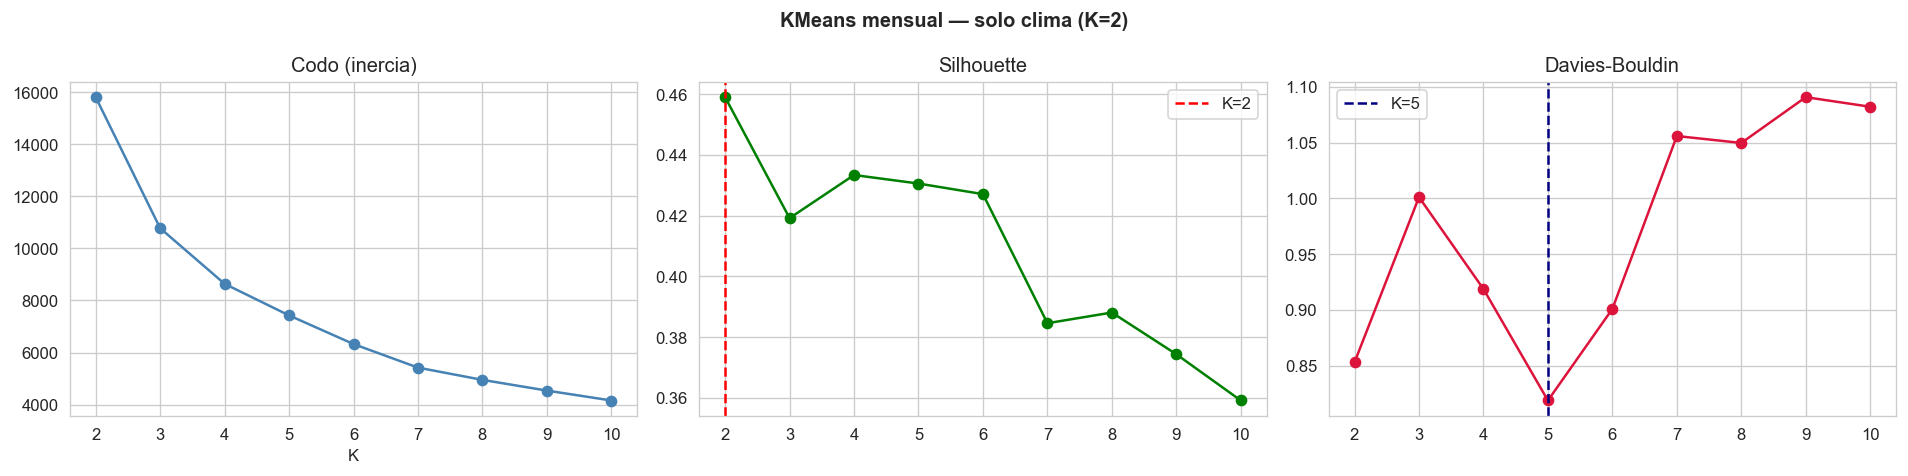

KMeans mensual K=2 | Sil=0.4590
DBSCAN mensual eps=0.5 ms=3 | Sil=0.4664 | ruido=15.5%


In [13]:
# ====================================================================
# CELDA: KMeans y DBSCAN sobre filas mensuales (solo clima)
# ====================================================================
# Análisis COMPLEMENTARIO: clustering directo de observaciones mes×distrito
# sin agregar por cultivo. K barrido 2..10 (más filas que perfiles).
# DBSCAN con rejilla más amplia (eps y min_samples mayores por n≈2376).
# Métricas guardadas en variables sil_mensual_*, pct_noise_m para tabla final.
# Advertencia: interpretabilidad Baja — no usar como resultado principal del paper.

# Barrido KMeans mensual sobre X_clima (12 vars estandarizadas).
km_mensual_df = eval_kmeans_range(X_clima, k_range=range(2, 11))
K_MENSUAL, _ = elegir_k(km_mensual_df)
plot_k_selection(km_mensual_df, f"KMeans mensual — solo clima (K={K_MENSUAL})")

# Ajuste final KMeans mensual.
km_mensual = KMeans(n_clusters=K_MENSUAL, random_state=42, n_init=10)
labels_mensual_km = km_mensual.fit_predict(X_clima)
sil_mensual_km = silhouette_score(X_clima, labels_mensual_km)
db_mensual_km = davies_bouldin_score(X_clima, labels_mensual_km)
print(f"KMeans mensual K={K_MENSUAL} | Sil={sil_mensual_km:.4f}")

# Grid DBSCAN mensual: más puntos → eps más pequeños y min_samples más altos.
res_db_mensual = grid_dbscan(
    X_clima,
    eps_list=[0.5, 0.8, 1.0, 1.2, 1.5, 2.0, 2.5, 3.0],
    ms_list=[3, 5, 10, 15],
)
if len(res_db_mensual):
    best_db_m = res_db_mensual.iloc[0]
    labels_mensual_db = best_db_m["labels"].astype(int)
    sil_mensual_db = best_db_m["silhouette"]
    pct_noise_m = best_db_m["pct_ruido"]
    print(f"DBSCAN mensual eps={best_db_m['eps']} ms={int(best_db_m['min_samples'])} | Sil={sil_mensual_db:.4f} | ruido={pct_noise_m:.1f}%")
else:
    labels_mensual_db = np.full(len(df_clima), -1)
    sil_mensual_db = np.nan
    pct_noise_m = 100.0


### 5.2 PCA + clustering mensual

### Qué hace esta celda

PCA: varianza explicada, loadings PC1–PC2, clustering en espacio reducido.

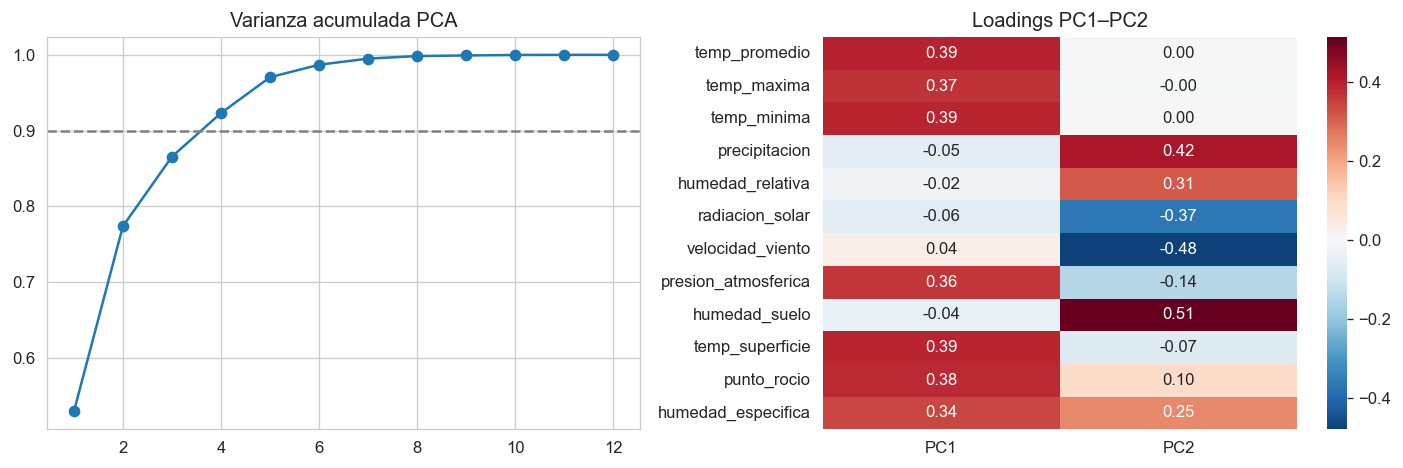

PCA (4 PCs) + KMeans K=2 | Sil=0.4901


In [14]:
# ====================================================================
# CELDA: PCA sobre filas mensuales — varianza, loadings y clustering
# ====================================================================
# Reducción lineal de 12 variables climáticas:
#   1) PCA completo → varianza acumulada y loadings PC1–PC2 (heatmap).
#   2) Selección de n_pc_90 componentes que explican ≥90% varianza (máx 8).
#   3) KMeans + DBSCAN en el espacio PCA reducido (menos dimensionalidad).
# Interpretabilidad Media: los clusters están en espacio de componentes, no en clima directo.

# Ajuste PCA sin truncar: examinar cuántas componentes capturan 90% de varianza.
pca_full = PCA(random_state=42)
pca_full.fit(X_clima)
var_ac = np.cumsum(pca_full.explained_variance_ratio_)
n_pc_90 = int(np.searchsorted(var_ac, 0.90) + 1)
n_pc_90 = max(2, min(n_pc_90, 8))

# Panel izquierdo: curva de varianza acumulada; derecho: loadings PC1 y PC2 por variable.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(range(1, len(var_ac) + 1), var_ac, "o-")
axes[0].axhline(0.9, ls="--", color="gray")
axes[0].set_title("Varianza acumulada PCA")
load = pd.DataFrame(pca_full.components_[:2].T, index=CLIMA_VARS, columns=["PC1", "PC2"])
sns.heatmap(load, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=axes[1])
axes[1].set_title("Loadings PC1–PC2")
plt.tight_layout()
plt.show()

# PCA truncado a n_pc_90 componentes → matriz X_pca para clustering en espacio reducido.
pca = PCA(n_components=n_pc_90, random_state=42)
X_pca = pca.fit_transform(X_clima)

km_pca_df = eval_kmeans_range(X_pca, k_range=range(2, 11))
K_PCA, _ = elegir_k(km_pca_df)
labels_pca_km = KMeans(n_clusters=K_PCA, random_state=42, n_init=10).fit_predict(X_pca)
sil_pca_km = silhouette_score(X_pca, labels_pca_km)

# DBSCAN en espacio PCA (distancias en componentes principales, no en clima original).
res_pca_db = grid_dbscan(X_pca, eps_list=[0.8, 1.2, 1.5, 2.0, 2.5], ms_list=[5, 10, 15, 20])
if len(res_pca_db):
    best_pca_db = res_pca_db.iloc[0]
    labels_pca_db = best_pca_db["labels"].astype(int)
    sil_pca_db = best_pca_db["silhouette"]
    pct_noise_pca = best_pca_db["pct_ruido"]
else:
    labels_pca_db = np.full(len(X_pca), -1)
    sil_pca_db = np.nan
    pct_noise_pca = 100.0
print(f"PCA ({n_pc_90} PCs) + KMeans K={K_PCA} | Sil={sil_pca_km:.4f}")


### Interpretación — PCA mensual

Muestra cuánta varianza climática capturan PC1–PC2 y qué variables cargan en cada componente. Análisis **complementario** con repetición temporal; no es el resultado principal del informe.

### 5.3 NMF + clustering mensual

### Qué hace esta celda

NMF: selección de componentes por codo, clustering en espacio NMF.

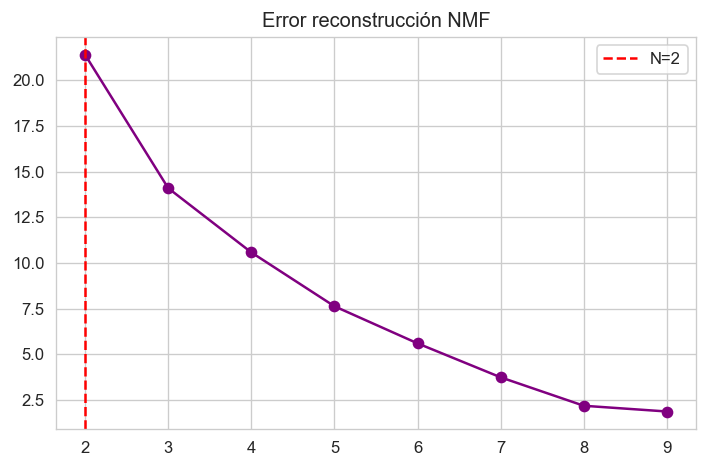

NMF (2) + KMeans K=2 | Sil=0.6043


In [15]:
# ====================================================================
# CELDA: NMF sobre filas mensuales — selección de componentes y clustering
# ====================================================================
# Factorización no negativa (NMF) sobre X_clima_mm (MinMax [0,1]):
#   - Barrido N=2..9: error de reconstrucción → codo para elegir N_NMF.
#   - fit_transform → espacio latente no negativo (patrones climáticos interpretables).
#   - KMeans + DBSCAN en X_nmf (análogo al bloque PCA).
# NMF asume datos ≥0; por eso se usa MinMax y no StandardScaler.

# Lista de errores de reconstrucción por número de componentes N.
nmf_errors = []
for n in range(2, 10):
    nmf_tmp = NMF(n_components=n, random_state=42, max_iter=500).fit(X_clima_mm)
    nmf_errors.append(nmf_tmp.reconstruction_err_)

# Criterio de codo simple: N donde la caída relativa del error es mínima (mayor curvatura).
drops = np.diff(nmf_errors)
N_NMF = int(np.argmin(drops) + 2) if len(drops) else 3
N_NMF = max(2, min(N_NMF, 8))

# Gráfico del error de reconstrucción vs N (línea vertical en N_NMF elegido).
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(range(2, 10), nmf_errors, "o-", color="purple")
ax.axvline(N_NMF, ls="--", color="red", label=f"N={N_NMF}")
ax.set_title("Error reconstrucción NMF")
ax.legend()
plt.tight_layout()
plt.show()

# NMF definitivo con N_NMF componentes → matriz X_nmf (filas × componentes latentes).
nmf = NMF(n_components=N_NMF, random_state=42, max_iter=500)
X_nmf = nmf.fit_transform(X_clima_mm)

# KMeans en espacio NMF.
km_nmf_df = eval_kmeans_range(X_nmf, k_range=range(2, 11))
K_NMF, _ = elegir_k(km_nmf_df)
labels_nmf_km = KMeans(n_clusters=K_NMF, random_state=42, n_init=10).fit_predict(X_nmf)
sil_nmf_km = silhouette_score(X_nmf, labels_nmf_km)

# DBSCAN en espacio NMF.
res_nmf_db = grid_dbscan(X_nmf, eps_list=[0.5, 1.0, 1.5, 2.0], ms_list=[5, 10, 15])
if len(res_nmf_db):
    best_nmf_db = res_nmf_db.iloc[0]
    labels_nmf_db = best_nmf_db["labels"].astype(int)
    sil_nmf_db = best_nmf_db["silhouette"]
    pct_noise_nmf = best_nmf_db["pct_ruido"]
else:
    labels_nmf_db = np.full(len(X_nmf), -1)
    sil_nmf_db = np.nan
    pct_noise_nmf = 100.0
print(f"NMF ({N_NMF}) + KMeans K={K_NMF} | Sil={sil_nmf_km:.4f}")


## 6. Comparativa final y exportación

### Qué hace esta celda

Tabla comparativa de métricas (Silhouette, DB, % ruido) para todos los métodos.

In [16]:
# ====================================================================
# CELDA: Tabla comparativa de métricas — todos los métodos y configuraciones
# ====================================================================
# Consolida Silhouette, Davies-Bouldin, % ruido DBSCAN e interpretabilidad
# para 9 configuraciones: 3 métodos × perfiles + 3 mensuales + 3 con reducción.
# Columnas: configuracion, unidad (perfil/mensual), metodo, reduccion (PCA/NMF/Ninguna).
# Output consola: tabla impresa + recomendado (mejor Silhouette en perfiles Alta).
# Este DataFrame se exporta luego como clustering_metricas.csv.

metricas = pd.DataFrame([
    {"configuracion": f"Perfil KMeans K={K_PERFIL}", "unidad": "perfil", "metodo": "KMeans",
     "reduccion": "Ninguna", "silhouette": sil_perfil_km, "davies_bouldin": db_perfil_km,
     "pct_ruido": 0.0, "interpretabilidad": "Alta"},
    {"configuracion": f"Perfil Jerárquico K={K_PERFIL}", "unidad": "perfil", "metodo": "Jerárquico",
     "reduccion": "Ninguna", "silhouette": sil_perfil_hc, "davies_bouldin": davies_bouldin_score(X_perfil, labels_perfil_hc),
     "pct_ruido": 0.0, "interpretabilidad": "Alta"},
    {"configuracion": "Perfil DBSCAN", "unidad": "perfil", "metodo": "DBSCAN",
     "reduccion": "Ninguna", "silhouette": sil_perfil_db, "davies_bouldin": np.nan,
     "pct_ruido": pct_noise_p if len(res_db_perfil) else 100.0, "interpretabilidad": "Alta"},
    {"configuracion": f"Mensual KMeans K={K_MENSUAL}", "unidad": "mensual", "metodo": "KMeans",
     "reduccion": "Ninguna", "silhouette": sil_mensual_km, "davies_bouldin": db_mensual_km,
     "pct_ruido": 0.0, "interpretabilidad": "Baja"},
    {"configuracion": "Mensual DBSCAN", "unidad": "mensual", "metodo": "DBSCAN",
     "reduccion": "Ninguna", "silhouette": sil_mensual_db, "davies_bouldin": np.nan,
     "pct_ruido": pct_noise_m, "interpretabilidad": "Baja"},
    {"configuracion": f"PCA+KMeans K={K_PCA}", "unidad": "mensual", "metodo": "KMeans",
     "reduccion": "PCA", "silhouette": sil_pca_km, "davies_bouldin": np.nan,
     "pct_ruido": 0.0, "interpretabilidad": "Media"},
    {"configuracion": "PCA+DBSCAN", "unidad": "mensual", "metodo": "DBSCAN",
     "reduccion": "PCA", "silhouette": sil_pca_db, "davies_bouldin": np.nan,
     "pct_ruido": pct_noise_pca, "interpretabilidad": "Media"},
    {"configuracion": f"NMF+KMeans K={K_NMF}", "unidad": "mensual", "metodo": "KMeans",
     "reduccion": "NMF", "silhouette": sil_nmf_km, "davies_bouldin": np.nan,
     "pct_ruido": 0.0, "interpretabilidad": "Media"},
    {"configuracion": "NMF+DBSCAN", "unidad": "mensual", "metodo": "DBSCAN",
     "reduccion": "NMF", "silhouette": sil_nmf_db, "davies_bouldin": np.nan,
     "pct_ruido": pct_noise_nmf, "interpretabilidad": "Media"},
])

# Redondeo de métricas numéricas para legibilidad en consola y CSV.
metricas[["silhouette", "davies_bouldin", "pct_ruido"]] = metricas[
    ["silhouette", "davies_bouldin", "pct_ruido"]
].round(4)
print(metricas.to_string(index=False))

# Recomendación para el informe: mejor Silhouette entre métodos de unidad=perfil (Alta interpretabilidad).
cand = metricas[(metricas["unidad"] == "perfil") & metricas["silhouette"].notna()]
recomendado = cand.loc[cand["silhouette"].idxmax(), "configuracion"]
print(f"\nRecomendado para el paper: {recomendado}")


        configuracion  unidad     metodo reduccion  silhouette  davies_bouldin  pct_ruido interpretabilidad
    Perfil KMeans K=6  perfil     KMeans   Ninguna      0.5137          0.6040     0.0000              Alta
Perfil Jerárquico K=6  perfil Jerárquico   Ninguna      0.5137          0.6040     0.0000              Alta
        Perfil DBSCAN  perfil     DBSCAN   Ninguna      0.8569             NaN    63.6364              Alta
   Mensual KMeans K=2 mensual     KMeans   Ninguna      0.4590          0.8529     0.0000              Baja
       Mensual DBSCAN mensual     DBSCAN   Ninguna      0.4664             NaN    15.5303              Baja
       PCA+KMeans K=2 mensual     KMeans       PCA      0.4901             NaN     0.0000             Media
           PCA+DBSCAN mensual     DBSCAN       PCA      0.4917             NaN     1.1785             Media
       NMF+KMeans K=2 mensual     KMeans       NMF      0.6043             NaN     0.0000             Media
           NMF+DBSCAN mensua

### Qué hace esta celda

Gráfico comparativo `comparativa_clustering.png`.

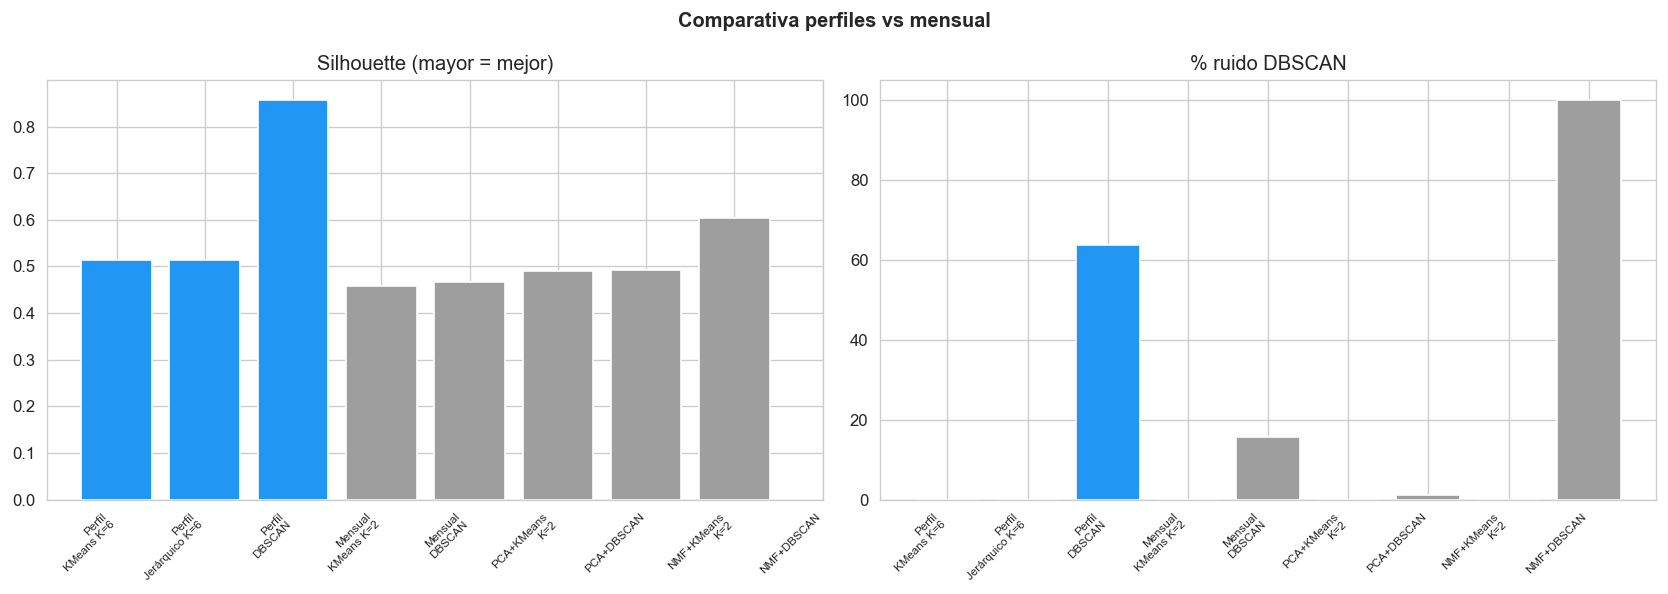

In [17]:
# ====================================================================
# CELDA: Gráfico comparativo comparativa_clustering.png
# ====================================================================
# Visualiza lado a lado Silhouette y % ruido DBSCAN para las 9 configuraciones.
# Azul (#2196F3) = métodos sobre perfiles (unidad principal); gris = mensuales.
# Output: OUTPUTS/figures/comparativa_clustering.png
# Permite defender en el paper por qué KMeans perfiles supera DBSCAN mensual.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Etiquetas abreviadas en eje X (salto de línea tras la primera palabra).
short = metricas["configuracion"].str.replace(" ", "\n", n=1)
colors = ["#2196F3" if u == "perfil" else "#9E9E9E" for u in metricas["unidad"]]

# Panel izquierdo: Silhouette — mayor barra = mejor cohesión/separación.
axes[0].bar(range(len(metricas)), metricas["silhouette"], color=colors)
axes[0].set_xticks(range(len(metricas)))
axes[0].set_xticklabels(short, fontsize=7, rotation=45, ha="right")
axes[0].set_title("Silhouette (mayor = mejor)")

# Panel derecho: % ruido DBSCAN — barras altas indican método poco usable (muchos -1).
axes[1].bar(range(len(metricas)), metricas["pct_ruido"], color=colors)
axes[1].set_xticks(range(len(metricas)))
axes[1].set_xticklabels(short, fontsize=7, rotation=45, ha="right")
axes[1].set_title("% ruido DBSCAN")

plt.suptitle("Comparativa perfiles vs mensual", fontweight="bold")
plt.tight_layout()
plt.savefig(RUTA_FIG / "comparativa_clustering.png", dpi=150, bbox_inches="tight")
plt.show()


### Interpretación — comparativa (`comparativa_clustering.png`)

Compara Silhouette y % ruido entre métodos. DBSCAN puede tener Silhouette alto pero >60% ruido → descartado como método principal. KMeans/Jerárquico sobre perfiles es la recomendación defendible.

### Qué hace esta celda

Exporta `clustering_perfiles.csv` y `clustering_metricas.csv`.

In [18]:
# ====================================================================
# CELDA: Exportación de resultados a CSV en OUTPUTS/
# ====================================================================
# Persiste dos artefactos reutilizables fuera del notebook:
#   - clustering_perfiles.csv: tabla_perfil (asignaciones por región×cultivo).
#   - clustering_metricas.csv: DataFrame metricas (comparativa de 9 métodos).
# encoding utf-8-sig para compatibilidad con Excel en Windows.

export_perfil = tabla_perfil.copy()
export_perfil.to_csv(RUTA_OUT / "clustering_perfiles.csv", index=False, encoding="utf-8-sig")
metricas.to_csv(RUTA_OUT / "clustering_metricas.csv", index=False, encoding="utf-8-sig")

print("Exportado:")
print(f"  {RUTA_OUT / 'clustering_perfiles.csv'}")
print(f"  {RUTA_OUT / 'clustering_metricas.csv'}")


Exportado:
  C:\Users\USER\OneDrive\Escritorio\Github\DM_TF\OUTPUTS\clustering_perfiles.csv
  C:\Users\USER\OneDrive\Escritorio\Github\DM_TF\OUTPUTS\clustering_metricas.csv


## 7. Conclusiones

### Qué hace esta celda

Imprime conclusiones y método recomendado (KMeans K=6 sobre perfiles).

In [19]:
# ====================================================================
# CELDA: Conclusiones impresas — síntesis para defensa e informe
# ====================================================================
# Resume en consola el método recomendado, composición de clusters KMeans,
# y hallazgos/limitaciones metodológicas del notebook 06.
# No genera archivos; cierra el pipeline de tipologías agroclimáticas.

print("=" * 60)
print("CONCLUSIONES")
print("=" * 60)
print(f"Método recomendado: {recomendado}")
print(f"Perfiles analizados: {len(df_perfil)} combinaciones (región, cultivo)")
print()

# Listado de cultivos y pisos por cluster KMeans (truncado si la lista es muy larga).
for c in sorted(df_perfil["cluster_kmeans"].unique()):
    sub = df_perfil[df_perfil["cluster_kmeans"] == c]
    cultivos = ", ".join(sub["region"] + "-" + sub["cultivo"])
    pisos = ", ".join(sorted(sub["piso_ecologico"].unique()))
    print(f"Cluster KMeans {c} ({len(sub)} cultivos):")
    print(f"  Cultivos: {cultivos[:200]}{'...' if len(cultivos)>200 else ''}")
    print(f"  Pisos: {pisos}")
    print()

print("Hallazgos:")
print("- El clustering por PERFIL agrupa cultivos con condiciones agroclimáticas similares.")
print("- El análisis MENSUAL infla Silhouette por 72 réplicas por cultivo; usar solo como complemento.")
print("- No se imputaron NaN de producción; coeficientes usan solo meses con dato real.")
print("- Limitación: 30 unidades — correlación no implica causalidad clima→producción.")


CONCLUSIONES
Método recomendado: Perfil DBSCAN
Perfiles analizados: 33 combinaciones (región, cultivo)

Cluster KMeans 0 (9 cultivos):
  Cultivos: Junin-cafe_pergamino, Junin-naranja, Junin-pina, Junin-platano, Junin-yuca, San Martin-arroz_cascara, San Martin-maiz_amarillo_duro, San Martin-palma_aceitera, San Martin-platano
  Pisos: selva_alta, selva_alto_mayo, selva_baja, selva_huallaga

Cluster KMeans 1 (10 cultivos):
  Cultivos: Ica-alfalfa, Ica-esparrago, Ica-maiz_amarillo_duro, Ica-mandarina, Ica-palta, Ica-papa, Ica-tomate, Ica-uva, La Libertad-arroz_cascara, La Libertad-palta
  Pisos: costa

Cluster KMeans 2 (3 cultivos):
  Cultivos: Puno-alfalfa, Puno-avena_forrajera, Puno-papa
  Pisos: altiplano_lacustre, puna_alta

Cluster KMeans 3 (1 cultivos):
  Cultivos: La Libertad-cana_para_azucar
  Pisos: costa

Cluster KMeans 4 (5 cultivos):
  Cultivos: Piura-arroz_cascara, Piura-cana_para_azucar, Piura-mango, Piura-platano, Piura-uva
  Pisos: bosque_seco, valle_chira

Cluster KMeans 5